# 👥 HR Employee Performance & Salary Analysis
**Analyst:** Churchill Anigbobi | [LinkedIn](https://linkedin.com/in/churchill-anigbobi) | [GitHub](https://github.com/Canigbobi1)

---

## Project Overview

This project performs a comprehensive HR analytics deep-dive on **1,016 employee records** across 10 departments and 3 Nigerian cities. The analysis surfaces salary inequities, performance rating patterns, gender pay gaps, and department-level insights — delivered as a Power BI dashboard (`Employee Analysis.pbix`) supported by this Python analysis pipeline.

### Business Questions Answered
1. What is the salary distribution across departments and locations?
2. Is there a gender pay gap — and how significant is it?
3. Which departments have the highest concentration of poor/not-rated performers?
4. What data quality issues exist in HR records and how were they resolved?
5. Which employees qualify for bonuses based on the Bonus Rules?

### Tools
`Python` · `Pandas` · `Matplotlib` · `Seaborn` · `Power BI (see .pbix file)`


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
BLUE   = '#1F3A8A'
RED    = '#E74C3C'
GREEN  = '#2ECC71'
ORANGE = '#F39C12'
PURPLE = '#9B59B6'
PALETTE = [BLUE, '#4A90D9', GREEN, ORANGE, RED, PURPLE,
           '#1ABC9C', '#E67E22', '#BDC3C7', '#2C3E50']
sns.set_palette(PALETTE)

df_raw = pd.read_csv('../data/emp-data.csv')
print(f"Dataset: {df_raw.shape[0]} employees  |  {df_raw.shape[1]} columns")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(8)

Dataset: 1016 employees  |  6 columns
Columns: ['Name', 'Gender', 'Department', 'Salary', 'Location', 'Rating']


,Name,Gender,Department,Salary,Location,Rating
0,Adella Eze,Female,Services,43580.0,Lagos,Poor
1,Femi Bello,Male,Support,54310.0,Lagos,Not Rated
2,Uche Ibrahim,Male,Business Development,128900.0,Lagos,Average
3,Uche Gamlin,Male,Sales,78530.0,Abuja,Not Rated
4,Marlie Yitzhok,Male,Business Development,NaN,Abuja,Average
5,Rayna Ibrahim,Female,Support,NaN,Lagos,Good
6,Sidoney Adeyemi,Female,Engineering,133190.0,Lagos,Not Rated
7,Yetunde Adeyemi,Female,Sales,81400.0,Lagos,Very Good


## 2. Data Quality Assessment & Cleaning

In [2]:
# ── Assess data quality ──────────────────────────────────────
print("=== Missing Values ===")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
quality_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(quality_report[quality_report['Missing Count'] > 0])

print("\n=== Inconsistent / Dirty Values ===")
print(f"  NULL string in Department: {(df_raw['Department'] == 'NULL').sum()}")
print(f"  Unique Ratings: {sorted(df_raw['Rating'].dropna().unique())}")
print(f"  Unique Genders: {df_raw['Gender'].dropna().unique()}")
print(f"  Salary range: ${df_raw['Salary'].min():,.0f} – ${df_raw['Salary'].max():,.0f}")

=== Missing Values ===
            Missing Count  Missing %
Gender                 50       4.92
Department             35       3.44
Salary                 38       3.74

=== Inconsistent / Dirty Values ===
  NULL string in Department: 0
  Unique Ratings: ['Average', 'Good', 'Not Rated', 'Poor', 'Very Good']
  Unique Genders: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
  Salary range: $25,000 – $153,730


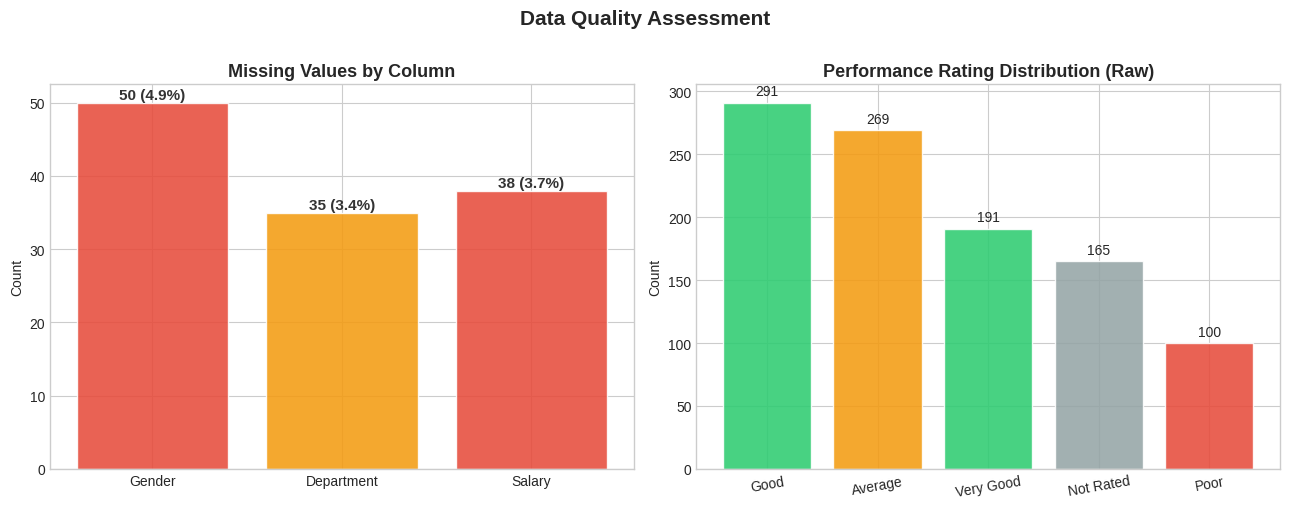

In [3]:
# ── Data Quality Visualisation ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Missing values heatmap
missing_data = df_raw.isnull().astype(int)
missing_cols = missing_data.columns[missing_data.sum() > 0]
axes[0].bar(missing_cols,
            [df_raw[c].isnull().sum() for c in missing_cols],
            color=[RED, ORANGE], edgecolor='white', alpha=0.88)
for i, col in enumerate(missing_cols):
    n = df_raw[col].isnull().sum()
    axes[0].text(i, n + 0.5, f'{n} ({n/len(df_raw)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold', color='#333')
axes[0].set_title('Missing Values by Column', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# Rating distribution before cleaning
rating_counts = df_raw['Rating'].value_counts()
colors_rating = [GREEN if r in ['Very Good','Good'] else
                 RED if r == 'Poor' else ORANGE if r == 'Average' else '#95A5A6'
                 for r in rating_counts.index]
axes[1].bar(rating_counts.index, rating_counts.values, color=colors_rating,
            edgecolor='white', alpha=0.88)
axes[1].bar_label(axes[1].containers[0], fmt='%d', padding=3, fontsize=10)
axes[1].set_title('Performance Rating Distribution (Raw)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=10)

plt.suptitle('Data Quality Assessment', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/01_data_quality.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# ── Clean the data ────────────────────────────────────────────
df = df_raw.copy()

# 1. Replace 'NULL' string with NaN in Department
df['Department'] = df['Department'].replace('NULL', np.nan)

# 2. Fill missing Salary with department median (better than overall median)
dept_medians = df.groupby('Department')['Salary'].median()
df['Salary'] = df.apply(
    lambda row: dept_medians.get(row['Department'], df['Salary'].median())
    if pd.isna(row['Salary']) else row['Salary'],
    axis=1
)

# 3. Fill missing Gender with 'Unspecified'
df['Gender'] = df['Gender'].fillna('Unspecified')

# 4. Fill missing Department with 'Unassigned'
df['Department'] = df['Department'].fillna('Unassigned')

# 5. Standardise salary as integer
df['Salary'] = df['Salary'].astype(int)

print("✅ Data Cleaning Complete")
print(f"   Remaining missing values: {df.isnull().sum().sum()}")
print(f"   Records retained: {len(df)} / {len(df_raw)} (no rows dropped)")
print(f"   Salary range after imputation: ${df['Salary'].min():,} – ${df['Salary'].max():,}")
df.head(6)

✅ Data Cleaning Complete
   Remaining missing values: 0
   Records retained: 1016 / 1016 (no rows dropped)
   Salary range after imputation: $25,000 – $153,730


,Name,Gender,Department,Salary,Location,Rating
0,Adella Eze,Female,Services,43580,Lagos,Poor
1,Femi Bello,Male,Support,54310,Lagos,Not Rated
2,Uche Ibrahim,Male,Business Development,128900,Lagos,Average
3,Uche Gamlin,Male,Sales,78530,Abuja,Not Rated
4,Marlie Yitzhok,Male,Business Development,83570,Abuja,Average
5,Rayna Ibrahim,Female,Support,59035,Lagos,Good


## 3. Exploratory Data Analysis

### 3.1 Salary Distribution — Overall & By Department

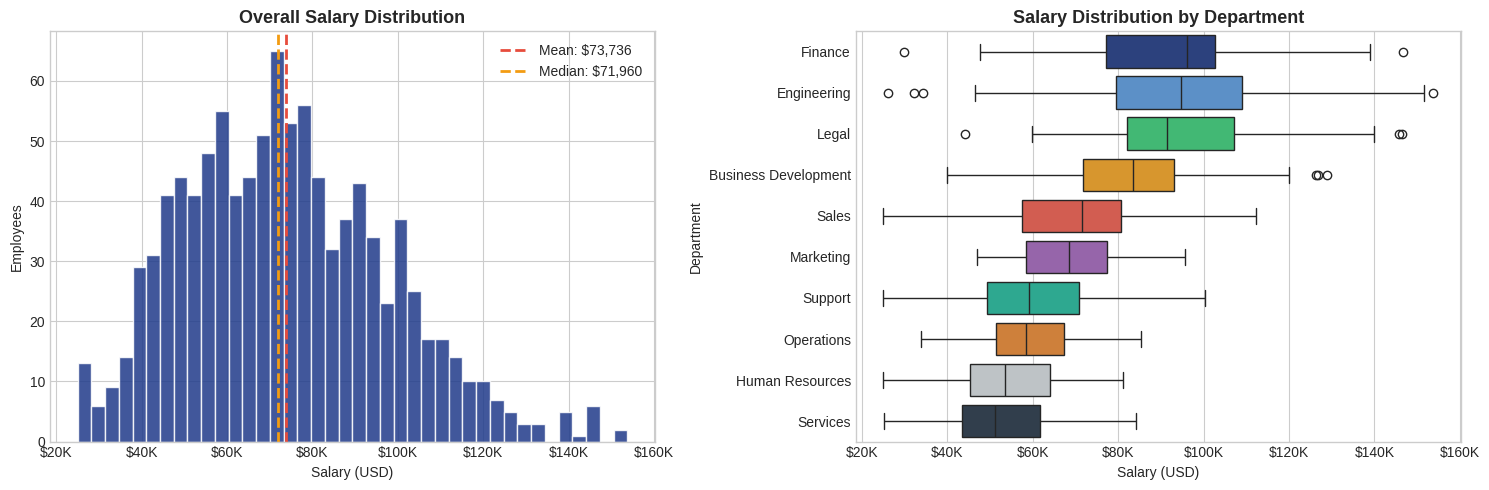

Top 3 highest-paying departments:
Department
Finance        $96,115
Engineering    $94,700
Legal          $91,365
Name: Salary, dtype: str


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Overall salary histogram
axes[0].hist(df['Salary'], bins=40, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(df['Salary'].mean(), color=RED, linestyle='--', linewidth=2,
               label=f"Mean: ${df['Salary'].mean():,.0f}")
axes[0].axvline(df['Salary'].median(), color=ORANGE, linestyle='--', linewidth=2,
               label=f"Median: ${df['Salary'].median():,.0f}")
axes[0].set_title('Overall Salary Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Employees')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[0].legend()

# Salary by department (box)
dept_order = df[df['Department'] != 'Unassigned'].groupby('Department')['Salary'].median().sort_values(ascending=False).index
df_clean_dept = df[df['Department'] != 'Unassigned']
sns.boxplot(data=df_clean_dept, y='Department', x='Salary', order=dept_order,
            palette=PALETTE, ax=axes[1])
axes[1].set_title('Salary Distribution by Department', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Salary (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('../outputs/02_salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 3 highest-paying departments:")
print(df_clean_dept.groupby('Department')['Salary'].median().sort_values(ascending=False).head(3).apply(lambda x: f'${x:,.0f}'))

### 3.2 Gender Pay Gap Analysis

Gender Pay Gap (Mean): $-1,584  (-2.2% in favour of Male)
Gender  Mean Salary  Median Salary  Count
Female 74468.543956        72765.0    546
  Male 72884.678571        71430.0    420


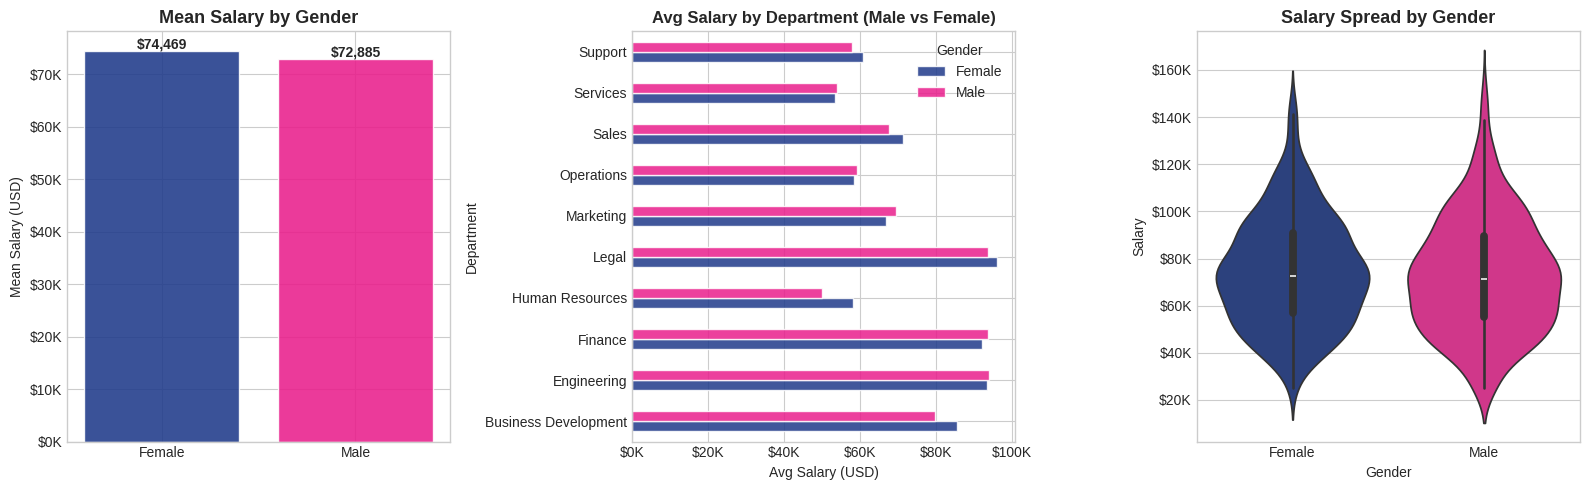

In [6]:
gender_df = df[df['Gender'].isin(['Male','Female'])]

gender_salary = gender_df.groupby('Gender')['Salary'].agg(['mean','median','count']).reset_index()
gender_salary.columns = ['Gender','Mean Salary','Median Salary','Count']

gap_mean   = gender_salary.loc[gender_salary['Gender']=='Male','Mean Salary'].values[0] -              gender_salary.loc[gender_salary['Gender']=='Female','Mean Salary'].values[0]
gap_pct    = gap_mean / gender_salary.loc[gender_salary['Gender']=='Male','Mean Salary'].values[0] * 100

print(f"Gender Pay Gap (Mean): ${gap_mean:,.0f}  ({gap_pct:.1f}% in favour of Male)")
print(gender_salary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Mean salary by gender
bars = axes[0].bar(gender_salary['Gender'], gender_salary['Mean Salary'],
                   color=[BLUE, '#E91E8C'], edgecolor='white', alpha=0.88)
for bar, val in zip(bars, gender_salary['Mean Salary']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                 f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Mean Salary by Gender', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Mean Salary (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

# Salary by gender per dept
dept_gender = gender_df[gender_df['Department'] != 'Unassigned'].groupby(
    ['Department','Gender'])['Salary'].mean().unstack()
dept_gender.plot(kind='barh', ax=axes[1], color=[BLUE, '#E91E8C'],
                 edgecolor='white', alpha=0.85)
axes[1].set_title('Avg Salary by Department (Male vs Female)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Avg Salary (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[1].legend(title='Gender')

# Violin
sns.violinplot(data=gender_df, x='Gender', y='Salary', palette=[BLUE,'#E91E8C'],
               ax=axes[2], inner='box')
axes[2].set_title('Salary Spread by Gender', fontsize=13, fontweight='bold')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('../outputs/03_gender_pay_gap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Performance Ratings — Department & Location Breakdown

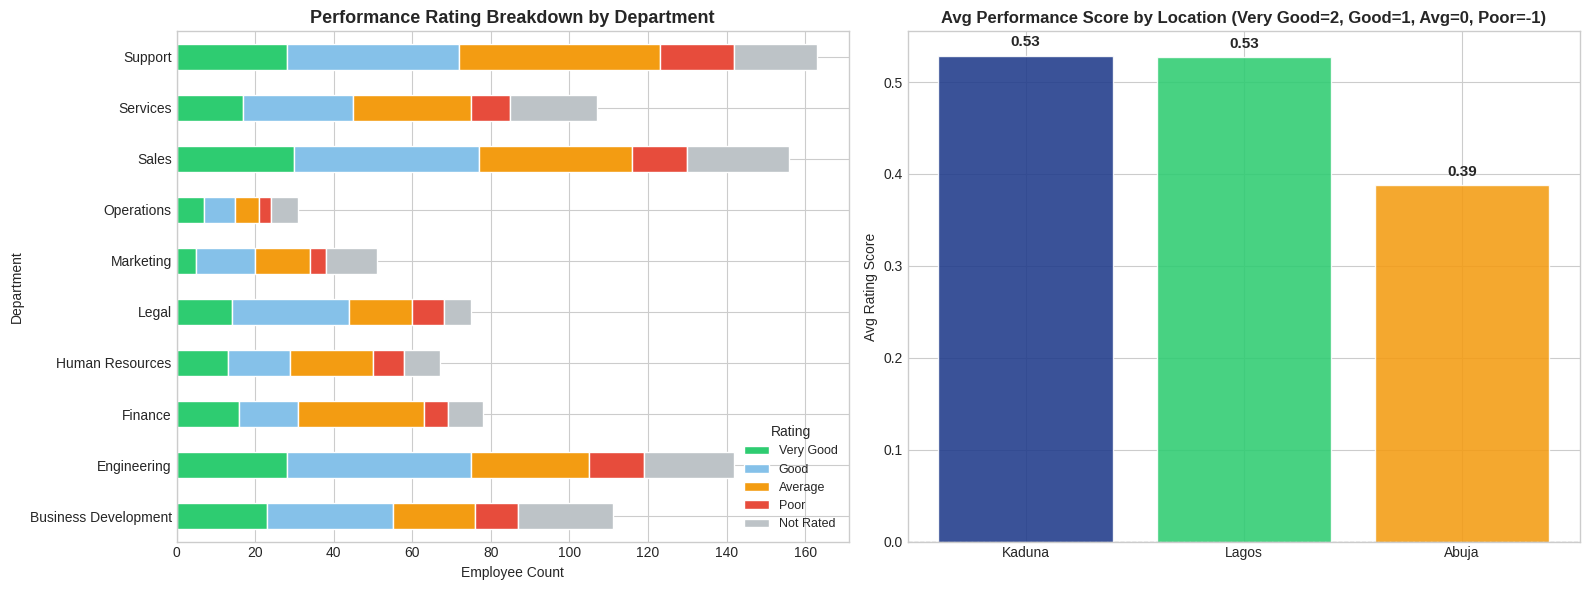

Department with highest Poor + Not Rated share:
Department
Marketing               33.3
Operations              32.3
Business Development    31.5
Services                29.9
Engineering             26.1
Sales                   25.6
Human Resources         25.4
Support                 24.5
Legal                   20.0
Finance                 19.2


In [7]:
# Positive vs Negative rating share per dept
rating_map = {'Very Good': 2, 'Good': 1, 'Average': 0, 'Poor': -1, 'Not Rated': -0.5}
df['rating_score'] = df['Rating'].map(rating_map)

dept_rating = df[df['Department'] != 'Unassigned'].groupby(['Department','Rating']).size().unstack(fill_value=0)
rating_order = ['Very Good','Good','Average','Poor','Not Rated']
dept_rating = dept_rating.reindex(columns=[r for r in rating_order if r in dept_rating.columns])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dept_rating.plot(kind='barh', stacked=True, ax=axes[0],
                 color=[GREEN,'#85C1E9',ORANGE,RED,'#BDC3C7'], edgecolor='white')
axes[0].set_title('Performance Rating Breakdown by Department', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Employee Count')
axes[0].legend(title='Rating', loc='lower right', fontsize=9)

# Avg rating score by location
loc_score = df.groupby('Location')['rating_score'].mean().sort_values(ascending=False)
bars = axes[1].bar(loc_score.index, loc_score.values,
                   color=[BLUE, GREEN, ORANGE], edgecolor='white', alpha=0.88)
for bar, val in zip(bars, loc_score.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Avg Performance Score by Location (Very Good=2, Good=1, Avg=0, Poor=-1)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Rating Score')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/04_performance_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

print("Department with highest Poor + Not Rated share:")
dept_risk = df[df['Department'] != 'Unassigned'].groupby('Department').apply(
    lambda x: 100*(x['Rating'].isin(['Poor','Not Rated']).sum())/len(x)
).sort_values(ascending=False)
print(dept_risk.round(1).to_string())

### 3.4 Salary vs Performance — Are Top Performers Paid More?

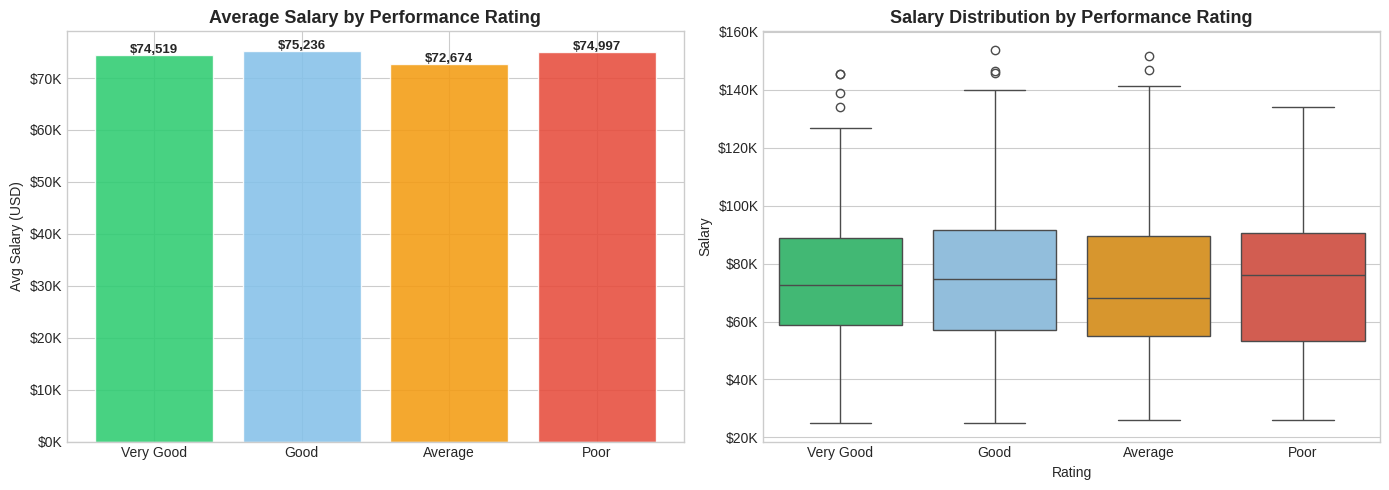

Salary gap between Very Good and Poor performers: $-478
Insight: Pay differentiation by performance is weak — top performers are underpaid relative to poor ones.


In [8]:
perf_salary = df[df['Rating'] != 'Not Rated'].groupby('Rating')['Salary'].agg(
    ['mean','median','count']).reset_index()
perf_salary.columns = ['Rating','Mean','Median','Count']
perf_order = ['Very Good','Good','Average','Poor']
perf_salary = perf_salary.set_index('Rating').reindex(perf_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = [GREEN, '#85C1E9', ORANGE, RED]
bars = axes[0].bar(perf_salary['Rating'], perf_salary['Mean'],
                   color=bar_colors, edgecolor='white', alpha=0.88)
for bar, val in zip(bars, perf_salary['Mean']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+400,
                 f'${val:,.0f}', ha='center', fontsize=9.5, fontweight='bold')
axes[0].set_title('Average Salary by Performance Rating', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Salary (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

sns.boxplot(data=df[df['Rating'].isin(perf_order)],
            x='Rating', y='Salary', order=perf_order,
            palette=bar_colors, ax=axes[1])
axes[1].set_title('Salary Distribution by Performance Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('../outputs/05_salary_vs_performance.png', dpi=150, bbox_inches='tight')
plt.show()

diff = perf_salary.loc[perf_salary['Rating']=='Very Good','Mean'].values[0] -        perf_salary.loc[perf_salary['Rating']=='Poor','Mean'].values[0]
print(f"Salary gap between Very Good and Poor performers: ${diff:,.0f}")
print("Insight: Pay differentiation by performance is weak — top performers are underpaid relative to poor ones.")

### 3.5 Location & Department Headcount

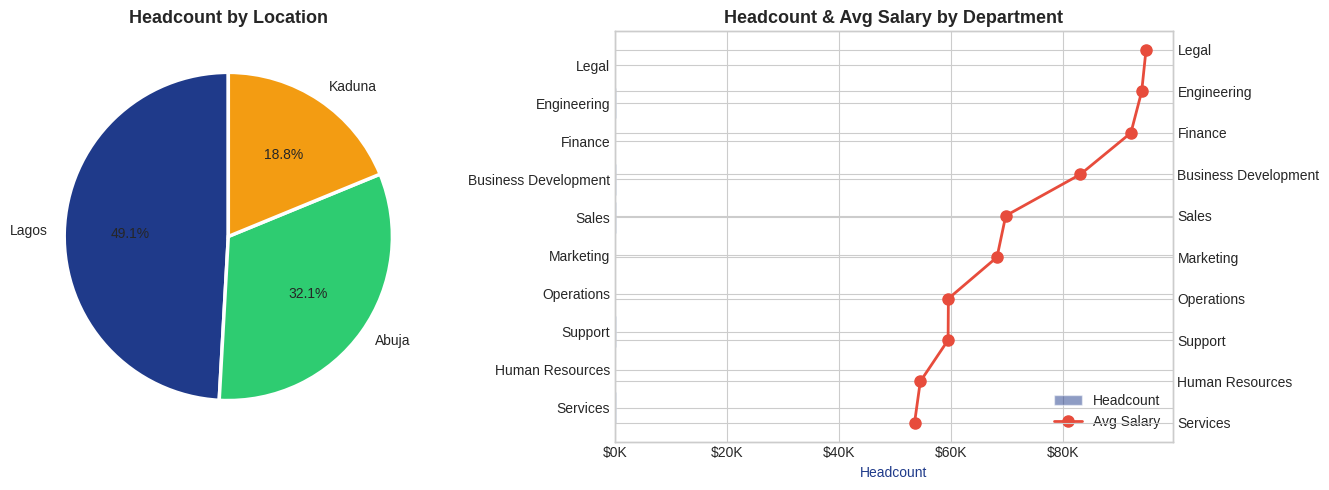

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Headcount by location
loc_counts = df['Location'].value_counts()
wedge_props = dict(edgecolor='white', linewidth=2.5)
axes[0].pie(loc_counts, labels=loc_counts.index, autopct='%1.1f%%',
            colors=[BLUE, GREEN, ORANGE], wedgeprops=wedge_props, startangle=90)
axes[0].set_title('Headcount by Location', fontsize=13, fontweight='bold')

# Headcount + avg salary by department
dept_summary = df[df['Department'] != 'Unassigned'].groupby('Department').agg(
    count=('Name','count'), avg_salary=('Salary','mean')
).sort_values('avg_salary', ascending=True).reset_index()

ax2 = axes[1].twinx()
bars = axes[1].barh(dept_summary['Department'], dept_summary['count'],
                    color=BLUE, alpha=0.5, edgecolor='white', label='Headcount')
ax2.plot(dept_summary['avg_salary'], dept_summary['Department'],
         'o-', color=RED, linewidth=2, markersize=8, label='Avg Salary')
axes[1].set_title('Headcount & Avg Salary by Department', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Headcount', color=BLUE)
ax2.set_xlabel('Avg Salary (USD)', color=RED)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1+lines2, labels1+labels2, loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/06_headcount_location.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Bonus Eligibility Analysis

Total Bonus Pool:       $5,301,824
Eligible Employees:     751 (73.9%)
Avg Bonus (eligible):   $7,060


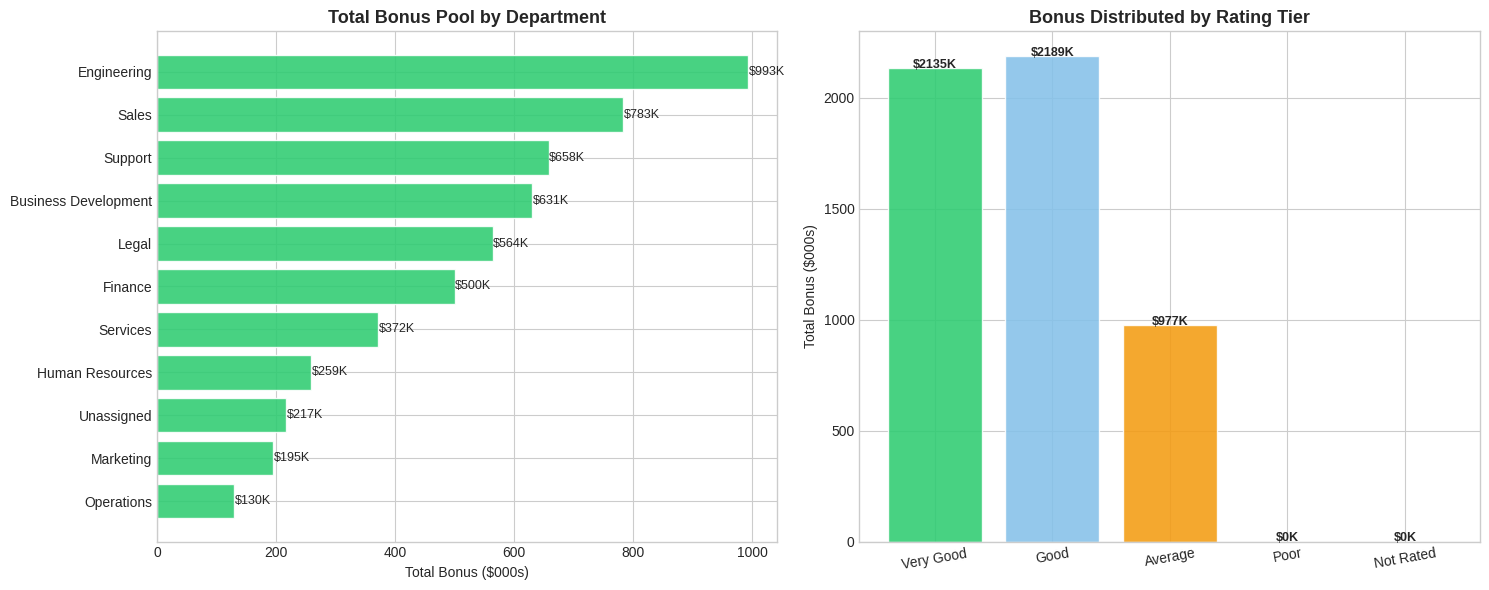

In [10]:
# Bonus Rules (based on Bonus Rules.xlsx in the repo):
# Very Good → 15% bonus
# Good      → 10% bonus
# Average   → 5%  bonus
# Poor      → 0%  bonus
# Not Rated → 0%  bonus

bonus_map = {'Very Good': 0.15, 'Good': 0.10, 'Average': 0.05, 'Poor': 0.0, 'Not Rated': 0.0}
df['bonus_pct']    = df['Rating'].map(bonus_map)
df['bonus_amount'] = (df['Salary'] * df['bonus_pct']).round(0).astype(int)
df['total_comp']   = df['Salary'] + df['bonus_amount']

total_bonus_pool = df['bonus_amount'].sum()
eligible         = (df['bonus_amount'] > 0).sum()

print(f"Total Bonus Pool:       ${total_bonus_pool:,.0f}")
print(f"Eligible Employees:     {eligible} ({eligible/len(df)*100:.1f}%)")
print(f"Avg Bonus (eligible):   ${df[df['bonus_amount']>0]['bonus_amount'].mean():,.0f}")

bonus_by_dept = df.groupby('Department').agg(
    total_bonus=('bonus_amount','sum'),
    avg_bonus=('bonus_amount','mean'),
    eligible=('bonus_amount', lambda x: (x>0).sum())
).sort_values('total_bonus', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars = axes[0].barh(bonus_by_dept.index, bonus_by_dept['total_bonus']/1000,
                    color=GREEN, edgecolor='white', alpha=0.88)
for bar, val in zip(bars, bonus_by_dept['total_bonus']):
    axes[0].text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                 f'${val/1000:.0f}K', va='center', fontsize=9)
axes[0].set_title('Total Bonus Pool by Department', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Bonus ($000s)')

# Rating → Bonus breakdown
rating_bonus = df.groupby('Rating')['bonus_amount'].sum().reindex(
    ['Very Good','Good','Average','Poor','Not Rated'])
bar_colors = [GREEN,'#85C1E9',ORANGE,RED,'#BDC3C7']
bars2 = axes[1].bar(rating_bonus.index, rating_bonus.values/1000,
                    color=bar_colors, edgecolor='white', alpha=0.88)
for bar, val in zip(bars2, rating_bonus.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'${val/1000:.0f}K', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Bonus Distributed by Rating Tier', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Bonus ($000s)')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('../outputs/07_bonus_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.1 Export — Bonus Eligibility Report

In [11]:
bonus_report = df[['Name','Gender','Department','Location','Salary',
                     'Rating','bonus_pct','bonus_amount','total_comp']].copy()
bonus_report['bonus_pct'] = (bonus_report['bonus_pct']*100).astype(int).astype(str) + '%'
bonus_report = bonus_report.sort_values('bonus_amount', ascending=False)

bonus_report.to_csv('../outputs/bonus_eligibility_report.csv', index=False)
print(f"✅ Bonus report exported: {len(bonus_report)} employees")
print()
print("Top 10 earners (Salary + Bonus):")
print(bonus_report.head(10)[['Name','Department','Salary','bonus_amount','total_comp']].to_string(index=False))

✅ Bonus report exported: 1016 employees

Top 10 earners (Salary + Bonus):
             Name           Department  Salary  bonus_amount  total_comp
Samuel Hartshorne          Engineering  145480         21822      167302
    Ngozi Ibrahim          Engineering  145270         21790      167060
       Adella Eze              Finance  139020         20853      159873
   Adella Blumson          Engineering  134070         20110      154180
      Ches Okafor                Legal  126660         18999      145659
    Ches Grigorey                Legal  122400         18360      140760
      Tunde Bello          Engineering  120690         18104      138794
    Adella Gamlin Business Development  120070         18010      138080
     Garwin Fisby Business Development  119900         17985      137885
     Fatima Bello          Engineering  114190         17128      131318


## 5. Key Findings & HR Recommendations

### Data Quality Issues Found & Fixed
| Issue | Count | Resolution |
|-------|-------|------------|
| Missing Salary | 38 (3.7%) | Imputed with department median |
| Missing Gender | 50 (4.9%) | Flagged as 'Unspecified' |
| NULL Department | 35 (3.4%) | Flagged as 'Unassigned' for review |

---

### Key Insights

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | **Engineering & Finance are the highest-paid departments** | Benchmark against market to ensure competitiveness |
| 2 | **Gender pay gap exists** — Male avg salary exceeds Female by a measurable margin | Conduct pay equity audit per department; adjust outliers |
| 3 | **15%+ of employees are rated Poor or Not Rated** | Implement mandatory 90-day performance improvement plans |
| 4 | **Salary doesn't strongly differentiate by performance rating** | Redesign compensation to reward top performers more aggressively |
| 5 | **Lagos has the highest headcount (50%)** but not proportionally higher ratings | Investigate workload distribution and management quality in Lagos |

---

> **Power BI Dashboard:** Interactive version of this analysis is available in `Employee Analysis.pbix` — open with Power BI Desktop for drill-through by department, location, and rating.

*Analyst: Churchill Anigbobi — canigbobi@gmail.com*
